## Experiment Workflow Test
Short notebook to validate the new experiment file workflow (`experiments/podmr.py` and `experiments/rabi.py`).

In [23]:
# Adjust if your VS Code kernel needs help finding pip / scripts
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [4]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from scipy.optimize import curve_fit
import qickdawg as qd
from importlib.metadata import version

print(f"numpy     {version('numpy')}")
print(f"qickdawg  {version('qickdawg')}")
print(f"python    {sys.version}")

numpy     2.3.3
qickdawg  1.2.1
python    3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


<a id="connect"></a>
### Connect to board

In [5]:
qd.start_client('192.168.3.1')
print("Connected — soccfg loaded:", qd.soccfg is not None)

Connected — soccfg loaded: True


In [6]:
default_config = qd.NVConfiguration()

default_config.adc_channel              = 0
default_config.mw_channel               = 0
default_config.mw_nqz                   = 1
default_config.mw_gain                  = 1800
default_config.laser_gate_pmod          = 0
default_config.laser_on_tus             = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns  = 300
default_config.mw_laser_delay_treg      = 0
default_config.relax_delay_tus          = 1.1
default_config.pre_init                 = True
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

<a id="top"></a>
# Table of Contents
1. [Connect to board](#connect)
2. [Laser](#laser)
3. [Counting Duration](#cd)
3. [PODMR](#podmr)
4. [RABI](#rabi)
5. [Ramsey](#ramsey)
6. [Hahn Echo](#hahn-echo)
7. [CPMG](#cpmg)
8. [CPMG Reopt Loop](#cpmg-reopt)

<a id="laser"></a>
### Laser
[Back to top](#top)

In [9]:
# Expected: laser should illuminate the sample
qd.laser_on(copy(default_config))

0

In [10]:
# Expected: laser should turn off
qd.laser_off(copy(default_config))

0

### PL counts — live scope

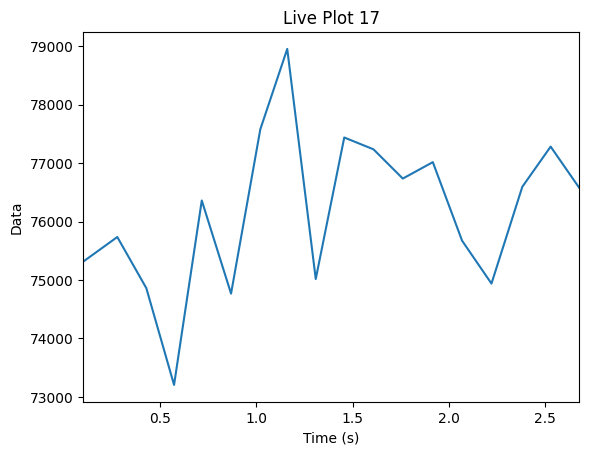

In [8]:
config = copy(default_config)
config.readout_integration_treg = 2**16 - 1
config.reps = 300
config.relax_delay_tns = 0

prog = qd.PLIntensity(config)

def get_cps():
    d = prog.acquire(progress=False)
    return d / (config.readout_integration_tus * 1e-6 * config.reps)

qd.live_plot(get_cps)

<a id="cd"></a>
### Counting Duration

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.


Counting-duration sweep:   0%|          | 0/150 [00:00<?, ?step/s]

Saved figure: c:\Users\QT3 User Facility\Documents\qick-dawg\data\counting_duration\counting_duration_full_res_20260331_162739_raw_and_subtracted.png
Saved figure: c:\Users\QT3 User Facility\Documents\qick-dawg\data\counting_duration\counting_duration_full_res_20260331_162739_snr.png


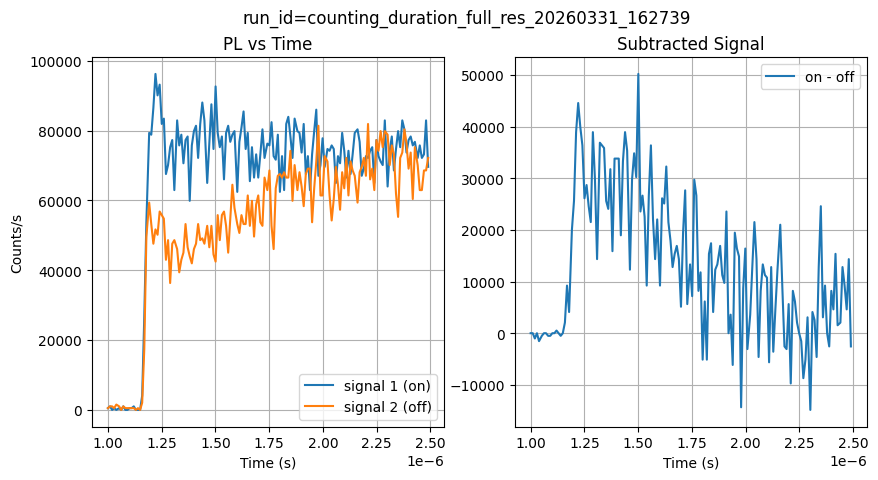

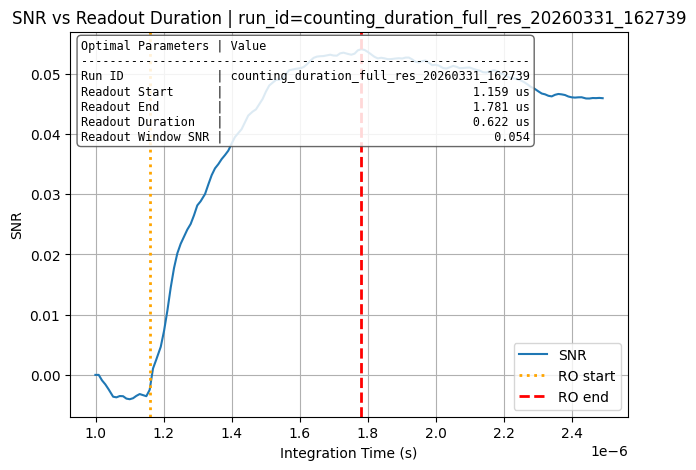

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/counting_duration.py

<a id="podmr"></a>
### PODMR
Edit parameters in `experiments/podmr.py` (EXPERIMENT PARAMETERS block), then run this cell.
The script handles connection, sweep config, acquisition, HDF5 save, and plot internally.
Use `%run -i` to inject variable overrides from a prior cell without editing the file.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 1844.5 to 1847.5 by 0.05
Instead using 1844.4999996185302 to 1847.5000225067138 by 0.05000038146972656 in 61 steps
[podmr] Sweep: 1844.500 -> 1847.500 MHz (delta 0.050 MHz)
[podmr] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=1200
[podmr] pi pulse: OVERRIDE_MW_PI_NS=950 ns


  0%|          | 0/12200000 [00:00<?, ?it/s]

[podmr] Saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260403_183003.h5
[podmr] Contrast dip fit: center=1845.343658 MHz, depth=0.345928, width=0.438803 MHz, baseline=1.00958


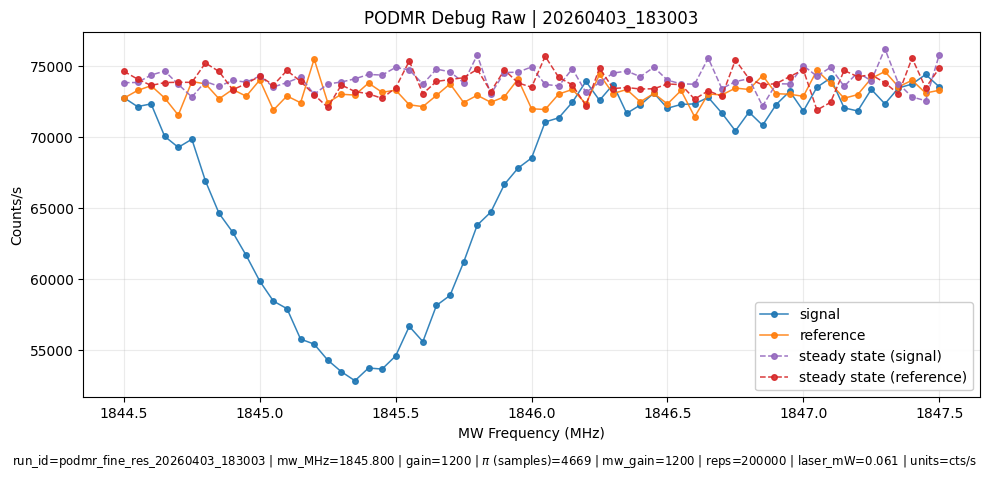

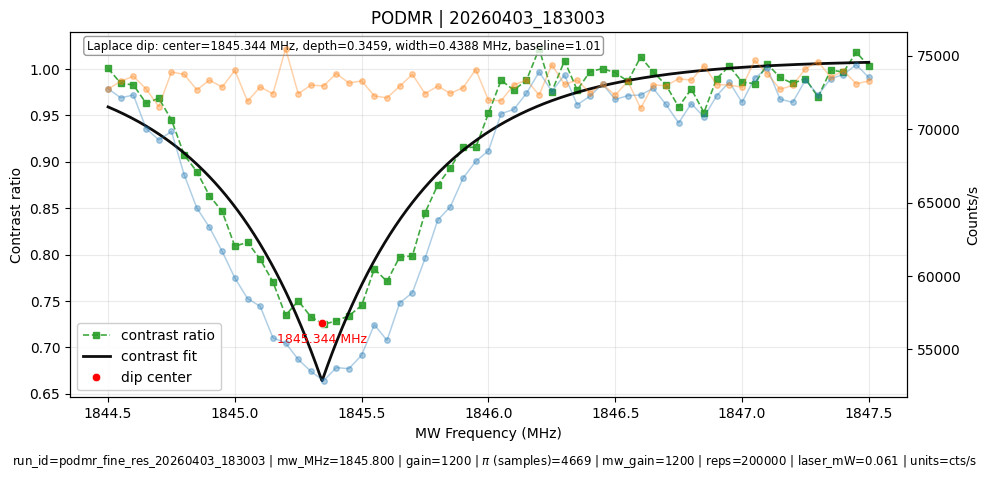

[podmr] Plot saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260403_183003.png


In [34]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/podmr.py

<a id="rabi"></a>
### RABI
Edit parameters in `experiments/rabi.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[rabi] Sweep: 50.000 -> 6000.000 ns (delta 50.000 ns)
[rabi] Active transition: lower_dip | freq=1845.8000003814695 MHz | gain=600

Requested 50 to 6000 by 50
Instead using 50.048828125 to 6005.859375 by 50.048828125 in 120 steps


  0%|          | 0/36000000 [00:00<?, ?it/s]

[rabi] Saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260403_184905.h5
[rabi] Contrast fit (decaying): A=0.029835, T=2175.463 ns, C=0.965189, tau=6879.653 ns


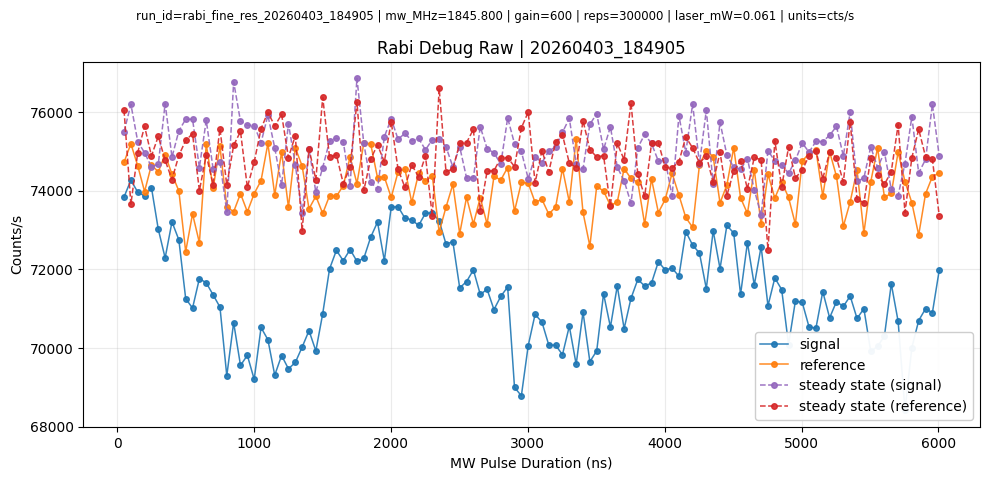

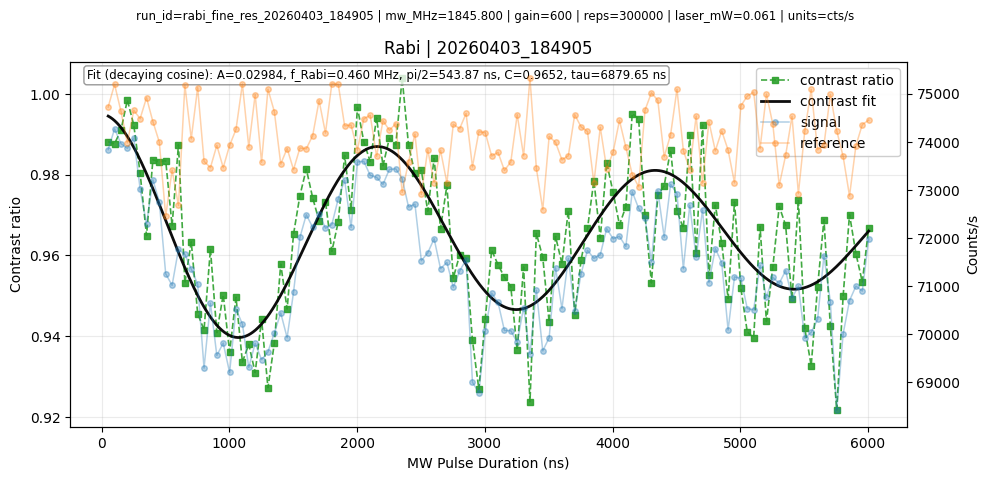

[rabi] Plot saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260403_184905.png


In [40]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/rabi.py

[rabi-like fit] Contrast fit (no decay): A=0.147826, T=108.566 ns, C=0.855748


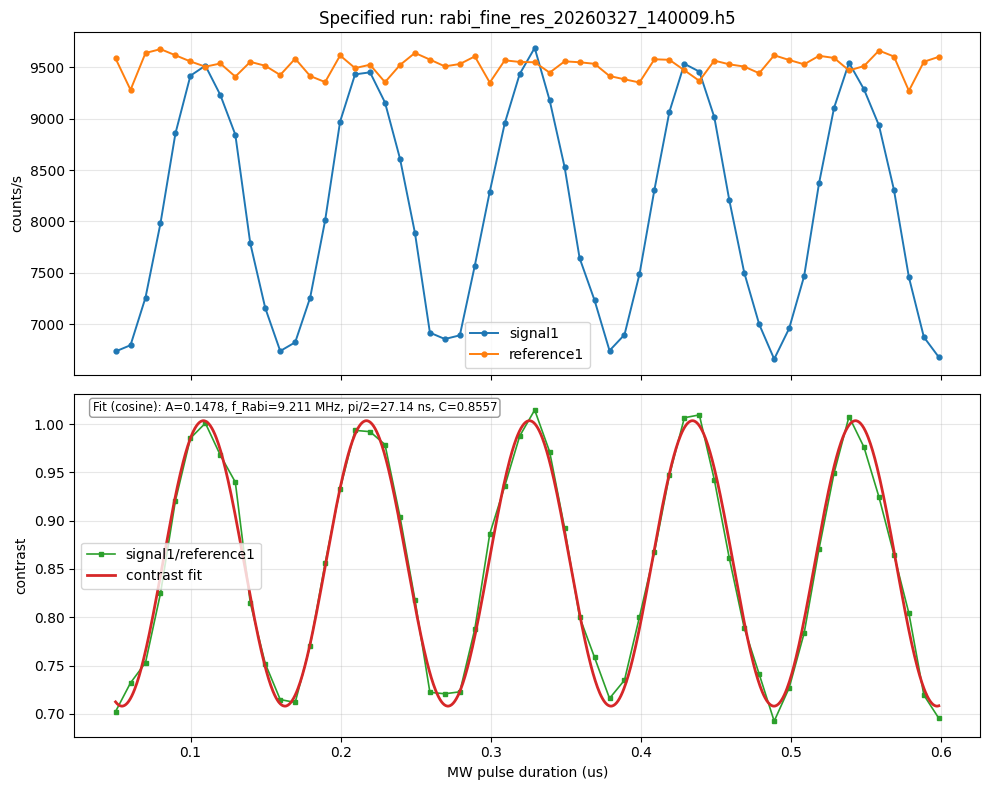

Loaded: C:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260327_140009.h5
axis=data/mw_duration_ftns, signal=data/signal1, reference=data/reference1, points=56


In [33]:
from pathlib import Path
import warnings

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, OptimizeWarning

PROJECT_ROOT = Path("..").resolve()
# Specified run file (relative to project root)
RUN_FILE = PROJECT_ROOT / "data" / "rabi" / "rabi_fine_res_20260327_140009.h5"

if not RUN_FILE.exists():
    raise FileNotFoundError(f"Could not find: {RUN_FILE.resolve()}")

def _find_dataset_key(h5f, candidate_names):
    found = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            leaf = Path(name).name
            if leaf in candidate_names:
                found.append(name)

    h5f.visititems(visitor)
    return found[0] if found else None

def _guess_rabi_period_ns(x_axis_ns, y):
    if len(x_axis_ns) < 4:
        return float(np.max(x_axis_ns) - np.min(x_axis_ns))

    dx = np.diff(x_axis_ns)
    if not np.all(dx > 0):
        return float(np.max(x_axis_ns) - np.min(x_axis_ns))

    dt = float(np.median(dx))
    if dt <= 0:
        return float(np.max(x_axis_ns) - np.min(x_axis_ns))

    y_centered = y - np.mean(y)
    freqs = np.fft.rfftfreq(len(y_centered), d=dt)
    spec = np.abs(np.fft.rfft(y_centered))
    if len(freqs) < 2:
        return float(np.max(x_axis_ns) - np.min(x_axis_ns))

    best_idx = int(np.argmax(spec[1:]) + 1)
    f0 = float(freqs[best_idx])
    if f0 <= 0:
        return float(np.max(x_axis_ns) - np.min(x_axis_ns))

    return 1.0 / f0

def _fit_rabi_contrast(x_axis_ns, y):
    # Same fit method used in experiments/rabi.py:
    # try decaying cosine first, then fallback to no-decay cosine.

    def decaying_cos(x, amplitude, period_ns, offset, tau_ns):
        return offset + amplitude * np.cos(2.0 * np.pi * x / period_ns) * np.exp(-x / tau_ns)

    def no_decay_cos(x, amplitude, period_ns, offset):
        return offset + amplitude * np.cos(2.0 * np.pi * x / period_ns)

    span = float(np.max(x_axis_ns) - np.min(x_axis_ns))
    if span <= 0:
        return None

    y_min = float(np.min(y))
    y_max = float(np.max(y))
    y_range = max(y_max - y_min, 1e-9)

    amplitude0 = 0.5 * y_range
    offset0 = float(np.mean(y))
    period0 = _guess_rabi_period_ns(x_axis_ns, y)
    period0 = float(np.clip(period0, max(1e-6, span / 20.0), max(span * 2.0, 1e-6)))
    tau0 = max(span, 1e-6)

    p0_full = [amplitude0, period0, offset0, tau0]
    bounds_full = (
        [0.0, max(1e-6, span / 50.0), y_min - y_range, max(1e-6, span / 50.0)],
        [3.0 * y_range, max(1e-6, span * 5.0), y_max + y_range, max(1e-6, span * 200.0)],
    )

    with warnings.catch_warnings():
        warnings.simplefilter("error", OptimizeWarning)
        try:
            params_full, _ = curve_fit(
                decaying_cos,
                x_axis_ns,
                y,
                p0=p0_full,
                bounds=bounds_full,
                maxfev=40000,
            )

            tau_fit = float(params_full[3])
            tau_effectively_infinite = tau_fit > 15.0 * span
            if not tau_effectively_infinite:
                fit_x = np.linspace(
                    float(np.min(x_axis_ns)),
                    float(np.max(x_axis_ns)),
                    max(500, len(x_axis_ns) * 20),
                )
                return {
                    "model": "decaying",
                    "params": params_full,
                    "fit_x": fit_x,
                    "fit_y": decaying_cos(fit_x, *params_full),
                }
        except (RuntimeError, ValueError, OptimizeWarning):
            pass

    p0_simple = [amplitude0, period0, offset0]
    bounds_simple = (
        [0.0, max(1e-6, span / 50.0), y_min - y_range],
        [3.0 * y_range, max(1e-6, span * 5.0), y_max + y_range],
    )

    try:
        params_simple, _ = curve_fit(
            no_decay_cos,
            x_axis_ns,
            y,
            p0=p0_simple,
            bounds=bounds_simple,
            maxfev=40000,
        )
        fit_x = np.linspace(
            float(np.min(x_axis_ns)),
            float(np.max(x_axis_ns)),
            max(500, len(x_axis_ns) * 20),
        )
        return {
            "model": "no_decay",
            "params": params_simple,
            "fit_x": fit_x,
            "fit_y": no_decay_cos(fit_x, *params_simple),
        }
    except (RuntimeError, ValueError):
        return None

with h5py.File(RUN_FILE, "r") as h5f:
    tau_key = _find_dataset_key(
        h5f,
        {"mw_duration_ftns", "mw_duration_ns", "mw_duration", "x_ns", "tau_ns", "tau_ftns"},
    )
    signal1_key = _find_dataset_key(h5f, {"signal1_cts_s", "signal1"})
    reference1_key = _find_dataset_key(h5f, {"reference1_cts_s", "reference1", "signal2_cts_s", "signal2"})

    if tau_key is None:
        raise KeyError("Could not find sweep-axis dataset for Rabi run.")
    if signal1_key is None:
        raise KeyError("Could not find signal1 dataset.")
    if reference1_key is None:
        raise KeyError("Could not find reference1 dataset.")

    x_ns = np.asarray(h5f[tau_key][()], dtype=float).reshape(-1)
    signal1 = np.asarray(h5f[signal1_key][()], dtype=float).reshape(-1)
    reference1 = np.asarray(h5f[reference1_key][()], dtype=float).reshape(-1)

n = min(len(x_ns), len(signal1), len(reference1))
if n < 4:
    raise ValueError(f"Need at least 4 points for fitting, got {n}.")

x_ns = x_ns[:n]
signal1 = signal1[:n]
reference1 = reference1[:n]
contrast_sr = signal1 / np.clip(reference1, 1e-12, None)

fit = _fit_rabi_contrast(x_ns, contrast_sr)
fit_summary_text = None
fit_x = None
fit_y = None

if fit is not None:
    fit_x = fit["fit_x"]
    fit_y = fit["fit_y"]
    amplitude = float(fit["params"][0])
    period_fit_ns = float(fit["params"][1])
    offset = float(fit["params"][2])
    pi2_ns = period_fit_ns / 4.0
    rabi_freq_mhz = 1000.0 / period_fit_ns

    if fit["model"] == "decaying":
        tau_fit_ns = float(fit["params"][3])
        fit_summary_text = (
            f"Fit (decaying cosine): A={amplitude:.4g}, "
            f"f_Rabi={rabi_freq_mhz:.3f} MHz, pi/2={pi2_ns:.2f} ns, "
            f"C={offset:.4g}, tau={tau_fit_ns:.2f} ns"
        )
        print(
            "[rabi-like fit] Contrast fit (decaying): "
            f"A={amplitude:.6g}, T={period_fit_ns:.3f} ns, "
            f"C={offset:.6g}, tau={tau_fit_ns:.3f} ns"
        )
    else:
        fit_summary_text = (
            f"Fit (cosine): A={amplitude:.4g}, "
            f"f_Rabi={rabi_freq_mhz:.3f} MHz, pi/2={pi2_ns:.2f} ns, "
            f"C={offset:.4g}"
        )
        print(
            "[rabi-like fit] Contrast fit (no decay): "
            f"A={amplitude:.6g}, T={period_fit_ns:.3f} ns, C={offset:.6g}"
        )
else:
    fit_summary_text = "Fit: did not converge."
    print("[rabi-like fit] Contrast fit skipped: fit did not converge.")

x_us = x_ns / 1e3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(x_us, signal1, "o-", lw=1.4, ms=3.5, label="signal1")
ax1.plot(x_us, reference1, "o-", lw=1.4, ms=3.5, label="reference1")
ax1.set_ylabel("counts/s")
ax1.set_title(f"Specified run: {RUN_FILE.name}")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(x_us, contrast_sr, "s-", lw=1.2, ms=3.2, color="tab:green", label="signal1/reference1")
if fit_x is not None and fit_y is not None:
    ax2.plot(fit_x / 1e3, fit_y, "-", lw=2.0, color="tab:red", label="contrast fit")
ax2.set_xlabel("MW pulse duration (us)")
ax2.set_ylabel("contrast")
ax2.grid(alpha=0.3)
ax2.legend()

ax2.text(
    0.02,
    0.98,
    fit_summary_text,
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"),
)

plt.tight_layout()
plt.show()

print(f"Loaded: {RUN_FILE.resolve()}")
print(f"axis={tau_key}, signal={signal1_key}, reference={reference1_key}, points={n}")

<a id="ramsey"></a>
### Ramsey
Edit parameters in `experiments/ramsey.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 200.0 to 15000.0 by 100.0
Instead using 199.99186197916669 to 15014.444986979168 by 100.09765625 in 149 steps
[ramsey] Sweep: 199.992 -> 15014.445 ftns (linear, configured delta=100.098)
[ramsey] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=32767
[ramsey] mw_pi2_ftsamp=134, reps=80000


  0%|          | 0/11920000 [00:00<?, ?it/s]

[ramsey] Saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\ramsey\ramsey_fine_res_20260331_172358.h5
[ramsey] Contrast fit (exp decay fallback): A=-0.207865, T2*=3.507 us, C=0.858379


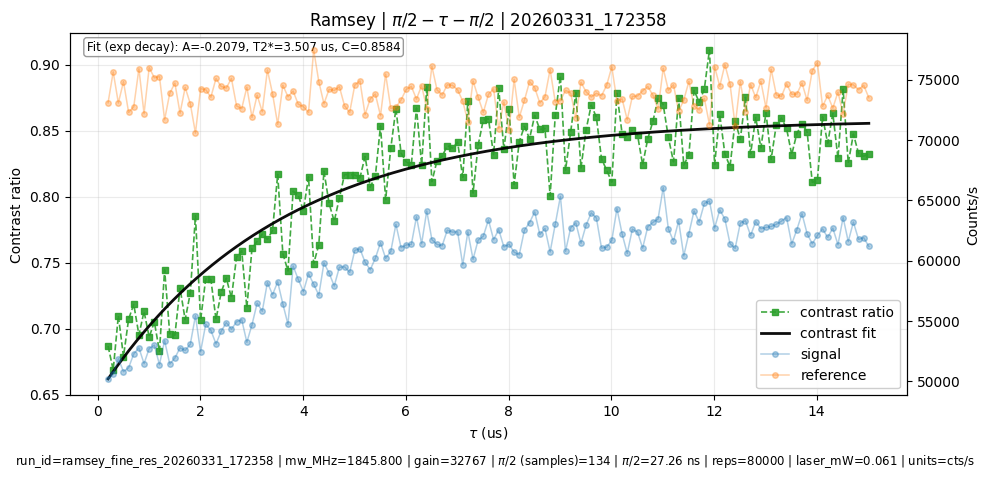

[ramsey] Plot saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\ramsey\ramsey_fine_res_20260331_172358.png


In [47]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/ramsey.py

In [200]:
config.mw_pi2_ftns = 26.95
config.mw_pi2_ftsamp

132

<a id="hahn-echo"></a>
### Hahn Echo
Edit parameters in `experiments/hahn_echo.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/hahn_echo.py

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[hahn_echo] Sweep: 199.992 -> 800000.000 ftns (exponential, scaling_factor=9/8, configured delta=0.000)
[hahn_echo] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=32767
[hahn_echo] mw_pi2_ftsamp=134, reps=50000


  0%|          | 0/2160000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


  0%|          | 0/2160000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


...

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


  0%|          | 0/2160000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


  0%|          | 0/2160000 [00:00<?, ?it/s]

[combine] wrote c:\Users\QT3 User Facility\Documents\qick-dawg\data\hahn_echo\hahn_echo_fine_res_run_20260406_012629\hahn_echo_fine_res_combined.h5
[hahn_echo_fine_res] Chunked run complete: {'run_id': '20260406_012629', 'run_dir': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629', 'manifest_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629\\run_manifest.jsonl', 'summary_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629\\run_summary.csv', 'combined_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629\\hahn_echo_fine_res_combined.h5'}


<a id="t1"></a>
### T1

[Laser](#laser) | [Top](#top)

In [13]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/t1.py

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[t1] Sweep: 999.349 -> 3000000.000 ns (exponential, scaling_factor=5/4, points=37)
[t1] Active transition: lower_dip | mw_gain=32767
[t1] pi pulse: calibration.lower_dip.mw_pi_ftsamp=268


  0%|          | 0/1110000 [00:00<?, ?it/s]

KeyboardInterrupt: 

<a id="cpmg"></a>
### CPMG
Edit parameters in `experiments/cpmg.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [58]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/cpmg.py

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 200.0 to 9000.0 by 5
Instead using 199.99186197916669 to 9151.814778645834 by 5.086263020833334 in 1761 steps
[cpmg] Sweep: 199.992 -> 9151.815 ftns (delta 5.086)
[cpmg] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=32767
[cpmg] n_cpmg=32, mw_pi2_ftsamp=134, reps=2000


  0%|          | 0/3522000 [00:00<?, ?it/s]

KeyboardInterrupt: 

<a id="cpmg-reopt"></a>
### CPMG Reopt Loop
Runs the long-loop reoptimization workflow using the regular system Python interpreter.
This avoids notebook-kernel environment mismatch for qdlutils/nidaq dependencies.

[Laser](#laser) | [Top](#top)

$stamp = Get-Date -Format "yyyyMMdd_HHmmss"; New-Item -ItemType Directory -Path "data/cpmg_reopt" -Force | Out-Null; $log = "data/cpmg_reopt/terminal_cpmg_reopt_$stamp.log"; $env:TQDM_DISABLE = "1"; & "C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe" -u "experiments/cpmg_reopt_loop.py" 2>&1 | Tee-Object -FilePath $log; Remove-Item Env:TQDM_DISABLE -ErrorAction SilentlyContinue

In [116]:
import subprocess
from pathlib import Path
import sys
import os
import glob

# Force regular system Python environment for this workflow
SYSTEM_PYTHON = r"C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe"
SCRIPT_PATH = Path("../experiments/cpmg_reopt_loop.py")

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Could not find script: {SCRIPT_PATH.resolve()}")

cmd = [SYSTEM_PYTHON, str(SCRIPT_PATH)]
print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(Path("..").resolve()))

print("\n=== STDOUT (tail) ===")
stdout_lines = proc.stdout.splitlines()
for line in stdout_lines[-80:]:
    print(line)

if proc.stderr.strip():
    print("\n=== STDERR (tail) ===")
    stderr_lines = proc.stderr.splitlines()
    for line in stderr_lines[-40:]:
        print(line)

print(f"\nExit code: {proc.returncode}")
if proc.returncode != 0:
    raise RuntimeError("cpmg_reopt_loop.py failed. Check output above.")

run_dirs = sorted(glob.glob(str(Path("../data/cpmg_reopt/cpmg_reopt_run_*"))), reverse=True)
if run_dirs:
    latest = Path(run_dirs[0])
    print(f"\nLatest run dir: {latest.resolve()}")
    plots_dir = latest / "plots"
    if plots_dir.exists():
        print("Plots:")
        for p in sorted(plots_dir.glob("*.png")):
            print(f"  - {p.name}")

Running: C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe ..\experiments\cpmg_reopt_loop.py

=== STDOUT (tail) ===

=== STDERR (tail) ===
C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe: can't open file 'C:\\Users\\QT3 User Facility\\Documents\\experiments\\cpmg_reopt_loop.py': [Errno 2] No such file or directory

Exit code: 2


RuntimeError: cpmg_reopt_loop.py failed. Check output above.

# Miscellaneous File Reading

In [40]:
from pathlib import Path
import h5py
import numpy as np

# Combined run file relative to ../data
# RUN_FILE = r"cpmg_reopt\cpmg_reopt_run_20260324_222413\cpmg_xy_fine_res_combined.h5"
RUN_FILE = r"cpmg_reopt/cpmg_reopt_run_20260325_162152/cpmg_xy_fine_res_combined.h5"

DATA_ROOT = Path("../data")
run_path = DATA_ROOT / RUN_FILE
if not run_path.exists():
    raise FileNotFoundError(f"Could not find: {run_path.resolve()}")

def _decode_if_bytes(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    return value

def _collect_attrs(h5f):
    attrs = {}
    for k, v in h5f.attrs.items():
        attrs[k] = _decode_if_bytes(v)
    for group_name in ("experiment", "resolved_config", "data"):
        if group_name in h5f:
            for k, v in h5f[group_name].attrs.items():
                attrs[k] = _decode_if_bytes(v)
    return attrs

def _find_dataset(datasets, names):
    for name in names:
        for k in datasets:
            if Path(k).name == name:
                return k
    return None

def _coerce_float(value):
    try:
        if value is None:
            return None
        out = float(value)
        return out if np.isfinite(out) else None
    except Exception:
        return None

def _get_tau_ns(tau_values, tau_key, attrs, datasets):
    tau_name = Path(tau_key).name

    # These datasets are already in nanoseconds scale for plotting.
    if tau_name in ("tau_ns", "tau_ftns", "tau_tus"):
        return tau_values, f"{tau_name} dataset"

    # Prefer explicit tau_ns/tau_ftns dataset if present anywhere in file.
    for preferred in ("tau_ns", "tau_ftns", "tau_tus"):
        preferred_key = _find_dataset(datasets, [preferred])
        if preferred_key is not None:
            tau_ns = np.asarray(datasets[preferred_key], dtype=float).reshape(-1)
            return tau_ns, f"{preferred} dataset"

    # Fall back to converting sample/tick-like axes to nanoseconds.
    ns_per_sample = None
    for k in ("ns_per_sample", "loop_ns_per_sample"):
        if k in attrs:
            ns_per_sample = _coerce_float(attrs[k])
            if ns_per_sample is not None:
                break

    if ns_per_sample is None:
        ns_per_sample = 0.20345052083333334
        print(
            "Warning: ns_per_sample metadata not found/invalid; using fallback "
            f"{ns_per_sample} ns/sample."
        )

    return tau_values * ns_per_sample, f"{tau_name} converted with ns_per_sample={ns_per_sample:.9g}"

datasets = {}
with h5py.File(run_path, "r") as h5f:
    attrs = _collect_attrs(h5f)
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)

tau_key = _find_dataset(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_tdds", "tau_samples", "sweep_pts"])
signal_key = _find_dataset(datasets, ["signal1_cts_s", "signal1"])
reference_key = _find_dataset(datasets, ["signal2_cts_s", "signal2"])
contrast_key = _find_dataset(datasets, ["contrast"])

if tau_key is None:
    raise KeyError("No tau dataset found (tried tau_ns/tau_ftns/tau_tus/tau_tdds/tau_samples/sweep_pts).")
if signal_key is None or reference_key is None:
    raise KeyError("Missing signal/reference datasets in combined file.")

tau_raw = np.asarray(datasets[tau_key], dtype=float).reshape(-1)
tau_ns, tau_ns_source = _get_tau_ns(tau_raw, tau_key, attrs, datasets)
signal = np.asarray(datasets[signal_key], dtype=float).reshape(-1)
reference = np.asarray(datasets[reference_key], dtype=float).reshape(-1)

if contrast_key is not None:
    contrast = np.asarray(datasets[contrast_key], dtype=float).reshape(-1)
else:
    contrast = signal / np.clip(reference, 1e-12, None)

print(f"Loaded combined file: {run_path.resolve()}")
print(f"tau source: {tau_key}")
print(f"tau_ns conversion: {tau_ns_source}")
print(f"signal source: {signal_key}")
print(f"reference source: {reference_key}")
print(f"contrast source: {contrast_key if contrast_key is not None else 'computed signal/reference'}")
print(f"points: tau={len(tau_ns)}, signal={len(signal)}, reference={len(reference)}, contrast={len(contrast)}")

Loaded combined file: C:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\cpmg_reopt_run_20260325_162152\cpmg_xy_fine_res_combined.h5
tau source: /data/tau_ftns
tau_ns conversion: tau_ftns dataset
signal source: /data/signal1_cts_s
reference source: /data/signal2_cts_s
contrast source: /data/contrast
points: tau=161, signal=161, reference=161, contrast=161


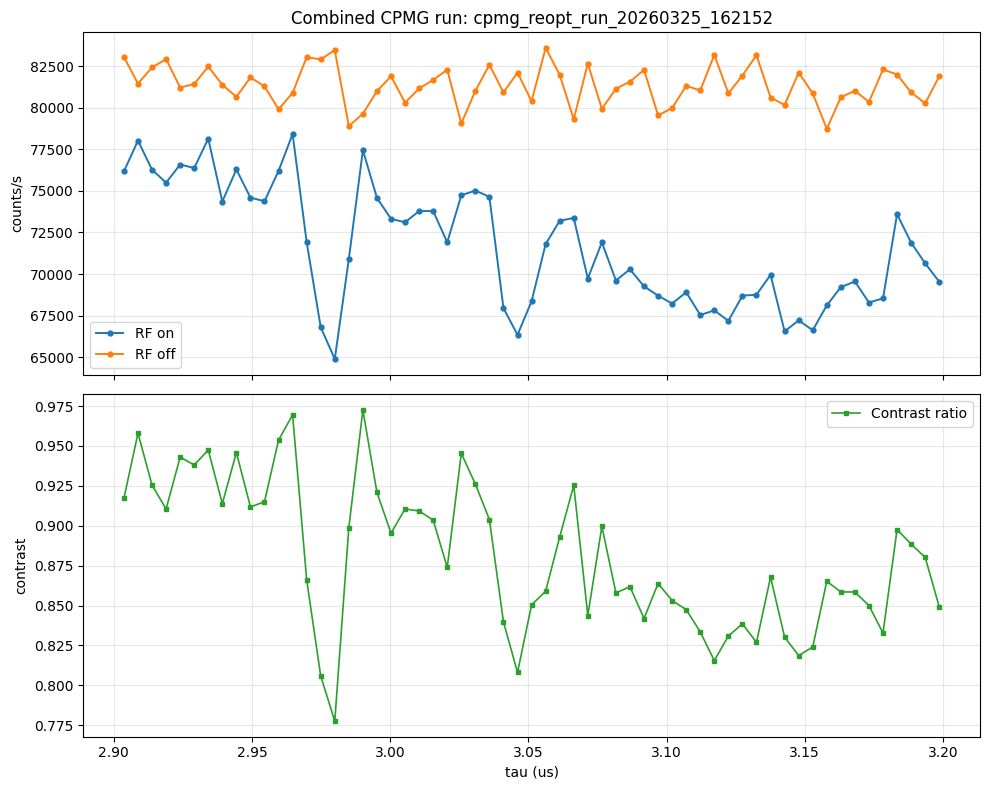

Plotted 161 signal points, 161 reference points, 161 contrast points vs tau (ns).


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Requires variables produced by the previous cell:
# tau_ns, signal, reference, contrast, run_path
required_vars = ["tau_ns", "signal", "reference", "contrast", "run_path"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(f"Run the previous combined-data extraction cell first. Missing: {missing}")

x = np.asarray(tau_ns/1e3, dtype=float).reshape(-1)
y_sig = np.asarray(signal, dtype=float).reshape(-1)
y_ref = np.asarray(reference, dtype=float).reshape(-1)
y_con = np.asarray(contrast, dtype=float).reshape(-1)

n_sig = min(len(x), len(y_sig))
n_ref = min(len(x), len(y_ref))
n_con = min(len(x), len(y_con))

# x is in microseconds (x = tau_ns / 1e3), so mask in us (not seconds)
mask = (x >= 2.9) & (x <= 3.2)
x = x[mask]
y_sig = y_sig[mask]
y_ref = y_ref[mask]
y_con = y_con[mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(x[:n_sig], y_sig[:n_sig], "o-", lw=1.4, ms=3.5, label="RF on")
ax1.plot(x[:n_ref], y_ref[:n_ref], "o-", lw=1.4, ms=3.5, label="RF off")
ax1.set_ylabel("counts/s")
run_dir_name = run_path.parent.name
ax1.set_title(f"Combined CPMG run: {run_dir_name}")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(x[:n_con], y_con[:n_con], "s-", lw=1.2, ms=3.2, color="tab:green", label="Contrast ratio")
ax2.set_xlabel("tau (us)")
ax2.set_ylabel("contrast")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Plotted {n_sig} signal points, {n_ref} reference points, {n_con} contrast points vs tau (ns).")

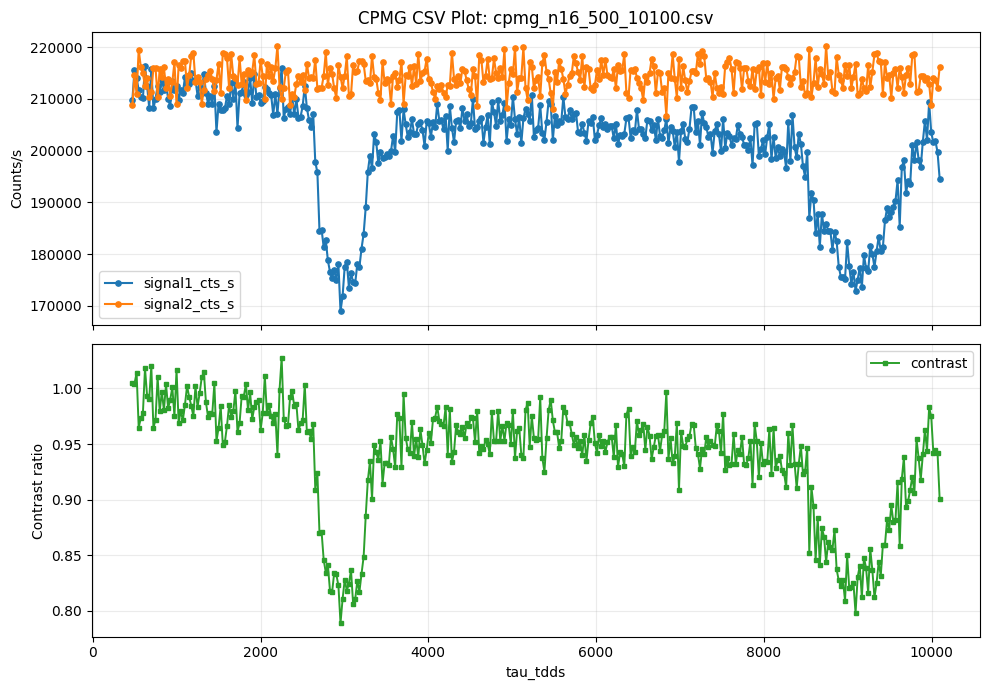

Plotted 385 rows from cpmg_n16_500_10100.csv


In [73]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = Path("cpmg_n16_500_10100.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find {csv_path.resolve()}")

df = pd.read_csv(csv_path)

required = ["tau_tdds", "signal1_cts_s", "signal2_cts_s", "contrast"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

tau_tdds = df["tau_tdds"].to_numpy(dtype=float)
signal = df["signal1_cts_s"].to_numpy(dtype=float)
reference = df["signal2_cts_s"].to_numpy(dtype=float)
contrast = df["contrast"].to_numpy(dtype=float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(tau_tdds, signal, "o-", lw=1.5, ms=3.8, label="signal1_cts_s")
ax1.plot(tau_tdds, reference, "o-", lw=1.5, ms=3.8, label="signal2_cts_s")
ax1.set_ylabel("Counts/s")
ax1.set_title(f"CPMG CSV Plot: {csv_path.name}")
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(tau_tdds, contrast, "s-", lw=1.4, ms=3.5, color="tab:green", label="contrast")
ax2.set_xlabel("tau_tdds")
ax2.set_ylabel("Contrast ratio")
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Plotted {len(df)} rows from {csv_path}")